In [6]:
# CELL 1: SETUP PARAMETER FISIK & DATA EKSPERIMEN (FIXED - IMPURITIES DIPECID)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import warnings
warnings.filterwarnings('ignore')

print("--- INISIALISASI PARAMETER ---")

# CELL 1: SETUP PARAMETER GEOMETRI
MODE = "5L" # Pilihan: "1L" atau "5L"

if MODE == "1L":
    D_tank = 0.12         # Diameter vessel (m)
    D_impeller = 0.04     # Diameter impeller (m)
    V_initial_L = 0.475   # Volume awal buffer di tangki (L)
    Np = 1.27             # Konstanta tipe impeller (Pitched Blade 45 deg)
else: # 5L
    D_tank = 0.205
    D_impeller = 0.075
    V_initial_L = 1.543   # Volume awal buffer di tangki (L)
    Np = 1.27

# =====================================================================
# DATA DUMMY TIME-SERIES
# Harus diganti dengan hasil experiment kinetik di 1 L nanti.
# =====================================================================
time_exp_dummy = np.array([0, 10, 30, 60, 90, 120])

data_exp_dummy = {
    'DesB30':     np.array([2.00, 1.20, 0.50, 0.20, 0.10, 0.05]),
    'Detemir':    np.array([0.00, 0.70, 1.20, 1.40, 1.45, 1.42]),
    'Impurity_A': np.array([0.15, 0.14, 0.13, 0.12, 0.11, 0.10]),
    'Impurity_B': np.array([0.00, 0.05, 0.15, 0.30, 0.40, 0.50]),
    'NHS_Myr':    np.array([0.00, 2.50, 1.00, 0.30, 0.10, 0.00])  
}

print(f"Kondisi Fisik Reaktor {MODE} & Data Dummy Berhasil Dimuat.")

--- INISIALISASI PARAMETER ---
Kondisi Fisik Reaktor 5L & Data Dummy Berhasil Dimuat.


In [7]:
# CELL 2: ENGINE KINETIKA KIMIA (FIXED - IMPURITIES SEPARATED)

# =====================================================================
# KETERANGAN QA/R&D:
# Nilai k di bawah ini adalah data pendekatan awal (DUMMY). Nilai riil 
# mutlak harus dicari kembali menggunakan fungsi optimasi (L-BFGS-B) 
# setelah data time-series HPLC 1L atau 5L Anda selesai di laboratorium.
# =====================================================================
k_conj = 0.15   # Laju pembentukan Detemir (DesB30 + NHS)
k_impB = 0.02   # Laju pembentukan Impurity B Baru (Detemir + NHS)
k_quench = 5.0  # Laju penangkapan sisa linker oleh Glisin (NHS + Glycine)

def to_mM(conc_mg_mL, mw):
    """
    Mengonversi konsentrasi dari mg/mL (satuan lapangan) ke mM (satuan kalkulus ODE).
    """
    if conc_mg_mL is None or mw is None:
        return 0.0
    return (conc_mg_mL / mw) * 1000.0

def calculate_reaction_rates(C_DesB30, C_NHS, C_Detemir, C_Glycine):
    """
    Menghitung laju reaksi kimia lokal (di dalam masing-masing zona tanki).
    Mengembalikan laju perubahan (r) untuk tiap komponen dalam mM/menit.
    """
    # Proteksi nilai batas bawah agar ODE solver tidak mengalami 'Math Domain Error'
    C_DesB30 = max(1e-9, C_DesB30)
    C_NHS = max(1e-9, C_NHS)
    C_Detemir = max(1e-9, C_Detemir)
    C_Glycine = max(0.0, C_Glycine)
    
    # 1. Jalur Utama: Pembentukan Insulin Detemir
    r_conj = k_conj * C_DesB30 * C_NHS
    
    # 2. Jalur Samping (Over-myristoylation): Detemir diserang lagi oleh NHS menjadi Impurity B
    # Perbaikan: Menggunakan konstanta spesifik k_impB untuk melacak degradasi Detemir
    r_impB = k_impB * C_Detemir * C_NHS
    
    # 3. Jalur Terminasi: Glisin mengikat mati sisa NHS-Myristate
    r_quench = k_quench * C_NHS * C_Glycine
    
    return r_conj, r_impB, r_quench

In [8]:
# CELL 3: THE 3-ZONE FED-BATCH ODE ENGINE (COMPLETELY ACCURATE - 19 STATES)

def simulate_scaleup(F_in_mL_min, h_clearance_ratio, t_quench_min, RPM_opt, C_Des_Init, C_NHS_stock, C_ImpA_Init, plot=False):
    F_in_L_min = F_in_mL_min / 1000.0
    C_Gly_stock = 500.0 
    F_Gly_L_min = 100.0 / 1000.0 
    durasi_quench = 1.0          
    
    N_rps = RPM_opt / 60.0
    Q_pump_L_min = (0.5 * N_rps * (D_impeller**3)) * 1000.0 * 60.0 
    Q_base = Q_pump_L_min / 15.0 
    V_active = 0.5 
    
    def fed_batch_ode(t, y):
        # UNPACK 19 VARIABLES (Dilacak per zona)
        DES1, DES2, DES3, NHS1, NHS2, NHS3, DET1, DET2, DET3, IMPA1, IMPA2, IMPA3, IMPB1, IMPB2, IMPB3, GLY1, GLY2, GLY3, V_tot = y
        
        V3 = max(0.01, V_tot * h_clearance_ratio - (V_active / 2))
        V1 = max(0.01, V_tot - V_active - V3)
        
        Q12 = Q_base * (h_clearance_ratio / 0.33)
        Q23 = Q_base * ((1.0 - h_clearance_ratio) / 0.67)
        
        current_F_NHS = F_in_L_min if t < t_quench_min else 0.0
        current_F_GLY = F_Gly_L_min if (t >= t_quench_min and t <= t_quench_min + durasi_quench) else 0.0 
        
        # Hitung reaksi kinetika riil di tiap zona
        r_c1, r_b1, r_q1 = calculate_reaction_rates(DES1, NHS1, DET1, GLY1)
        r_c2, r_b2, r_q2 = calculate_reaction_rates(DES2, NHS2, DET2, GLY2)
        r_c3, r_b3, r_q3 = calculate_reaction_rates(DES3, NHS3, DET3, GLY3)
        
        dV_tot = current_F_NHS + current_F_GLY
        dilution = dV_tot / V_tot
        
        # ZONE 1 (TOP FEED)
        dDES1 = (-Q12 * (DES1 - DES2) / V1) - r_c1 - (DES1 * dilution)
        dNHS1 = ((current_F_NHS * C_NHS_stock - Q12 * (NHS1 - NHS2)) / V1) - r_c1 - r_b1 - r_q1 - (NHS1 * dilution)
        dDET1 = (-Q12 * (DET1 - DET2) / V1) + r_c1 - r_b1 - (DET1 * dilution) # berkurang karena r_b1
        dIMPA1 = (-Q12 * (IMPA1 - IMPA2) / V1) - (IMPA1 * dilution)            # Murni terencerkan saja
        dIMPB1 = (-Q12 * (IMPB1 - IMPB2) / V1) + r_b1 - (IMPB1 * dilution)      # Tumbuh dari r_b1
        dGLY1 = ((current_F_GLY * C_Gly_stock - Q12 * (GLY1 - GLY2)) / V1) - r_q1 - (GLY1 * dilution)
        
        # ZONE 2 (ACTIVE IMPELLER)
        dDES2 = ((Q12 * (DES1 - DES2) - Q23 * (DES2 - DES3)) / V_active) - r_c2 - (DES2 * dilution)
        dNHS2 = ((Q12 * (NHS1 - NHS2) - Q23 * (NHS2 - NHS3)) / V_active) - r_c2 - r_b2 - (NHS2 * dilution)
        dDET2 = ((Q12 * (DET1 - DET2) - Q23 * (DET2 - DET3)) / V_active) + r_c2 - r_b2 - (DET2 * dilution)
        dIMPA2 = ((Q12 * (IMPA1 - IMPA2) - Q23 * (IMPA2 - IMPA3)) / V_active) - (IMPA2 * dilution)
        dIMPB2 = ((Q12 * (IMPB1 - IMPB2) - Q23 * (IMPB2 - IMPB3)) / V_active) + r_b2 - (IMPB2 * dilution)
        dGLY2 = ((Q12 * (GLY1 - GLY2) - Q23 * (GLY2 - GLY3)) / V_active) - r_q2 - (GLY2 * dilution)
        
        # ZONE 3 (BOTTOM BULK)
        dDES3 = ((Q23 * (DES2 - DES3)) / V3) - r_c3 - (DES3 * dilution)
        dNHS3 = ((Q23 * (NHS2 - NHS3)) / V3) - r_c3 - r_b3 - (NHS3 * dilution)
        dDET3 = ((Q23 * (DET2 - DET3)) / V3) + r_c3 - r_b3 - (DET3 * dilution)
        dIMPA3 = ((Q23 * (IMPA2 - IMPA3)) / V3) - (IMPA3 * dilution)
        dIMPB3 = ((Q23 * (IMPB2 - IMPB3)) / V3) + r_b3 - (IMPB3 * dilution)
        dGLY3 = ((Q23 * (GLY2 - GLY3)) / V3) - r_q3 - (GLY3 * dilution)
        
        return [dDES1, dDES2, dDES3, dNHS1, dNHS2, dNHS3, dDET1, dDET2, dDET3, 
                dIMPA1, dIMPA2, dIMPA3, dIMPB1, dIMPB2, dIMPB3, dGLY1, dGLY2, dGLY3, dV_tot]

    # Inisialisasi y0 awal (Impurity B mulai dari 0, Impurity A di-input)
    y0 = [C_Des_Init, C_Des_Init, C_Des_Init, 0, 0, 0, 0, 0, 0, 
          C_ImpA_Init, C_ImpA_Init, C_ImpA_Init, 0, 0, 0, 0, 0, 0, V_initial_L]
    
    sol = solve_ivp(fed_batch_ode, [0, t_quench_min + 30.0], y0, method='BDF', max_step=0.5)
    konversi_massa = (sol.y[8, -1] / C_Des_Init) * 100.0
    
    if plot:
        return sol.t, sol.y, konversi_massa
    return konversi_massa


🚀 Memulai Optimasi...

🎯 PARAMETERS
  [TARGET OUTPUT]     Prediksi Yield Detemir Bersih    : 59.33%
---------------------------------------------------------------------------
  [KONDISI OPERASI TANGKI / HIDRODINAMIKA]
  1. Kecepatan Agitasi / RPM Motor               : 336 RPM
  2. Posisi Tinggi Impeller dari Dasar Vessel    : 23.2% dari tinggi fluida
  3. Volumetric Flow Rate NHS                    : 10.1 mL/menit
  4. Waktu Penghentian Reaksi Pompa (t_rx)       : Menit ke-25.7
---------------------------------------------------------------------------
  [ KONDISI AWAL SUBSTRAT]
  5. Konsentrasi Awal Substrat Prekursor DesB30  : 2.88 mg/mL
  6. Batas Toleransi Maksimum IMPURITY A         : 0.422 mg/mL
  7. Konsentrasi Larutan Stok NHS-Myristate      : 3.24 mg/mL
---------------------------------------------------------------------------
  [PARAMETER FORMULASI QUENCHING STEP]
  8. Total Kebutuhan Massa Glisin                : 1.94 gram
  9. Volume Larutan Stok Glisin untuk Diinjeksi  

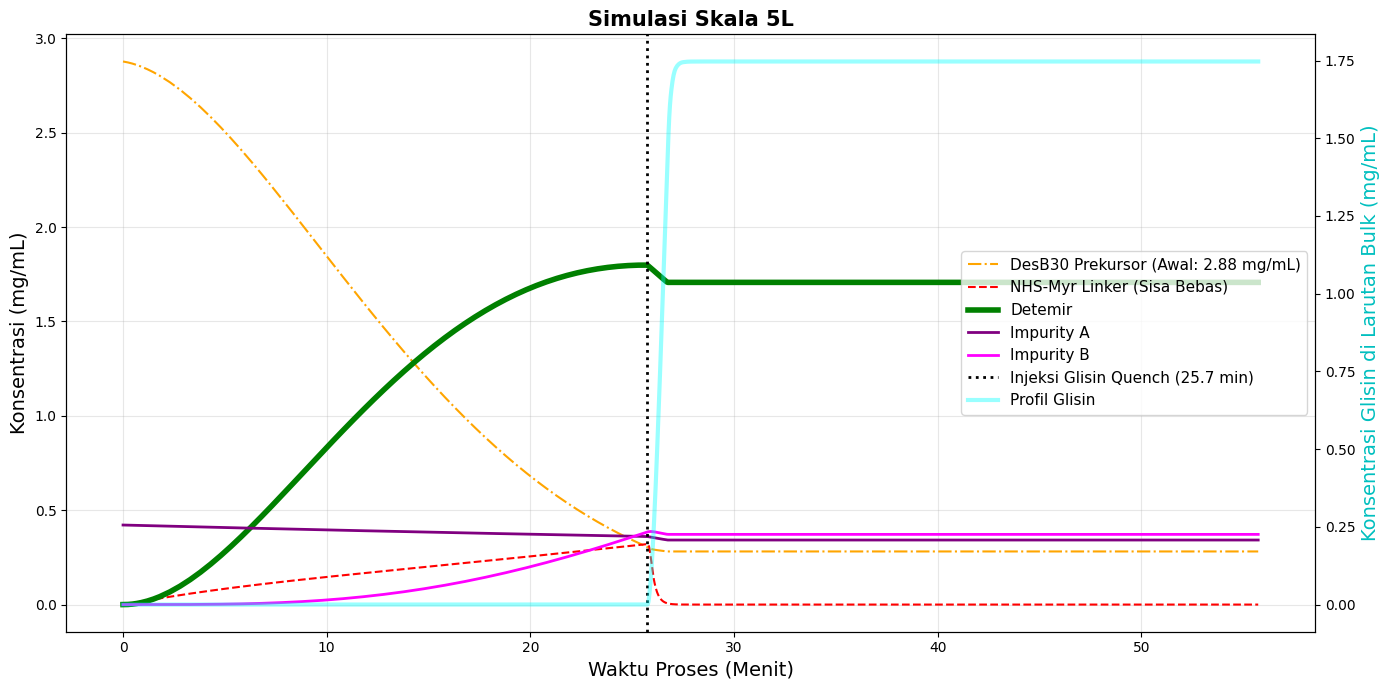

In [10]:
# CELL 4: OPTIMASI

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

print("\n🚀 Memulai Optimasi...")

# Fungsi konversi satuan ke mg/mL
def to_mg_mL(conc_mM, MW): return (conc_mM * MW) / 1000.0
def to_mM(conc_mg_mL, MW): return (conc_mg_mL / MW) * 1000.0

# Berat Molekul Komponen
MW_desb30 = 5706.0
MW_nhs_myr = 325.44
MW_glycine = 75.07
MW_impA = 5706.0  # Pendekatan MW Impurity A (karena strukturnya mirip protein dasar)
MW_impB = 6127.2  # MW Impurity B (Over-myristoylation)

def objective_function(params):
    F_in_mL_min, h_ratio, t_quench_min, RPM_opt, C_Des_Init, C_NHS_stock, C_ImpA_Init = params
    if t_quench_min < 2.0 or RPM_opt < 50.0: return 999.0
    yield_pct = simulate_scaleup(F_in_mL_min, h_ratio, t_quench_min, RPM_opt, C_Des_Init, C_NHS_stock, C_ImpA_Init, plot=False)
    return -yield_pct 

# Ruang batas pencarian AI
bounds = [
    (10.0, 300.0),   # 1. Laju Pompa F_in (mL/min)
    (0.10, 0.50),    # 2. Clearance Impeller (Ratio)
    (5.0, 60.0),     # 3. Waktu Quench (Menit)
    (100.0, 700.0),  # 4. RPM Impeller (Maks dikunci 700 RPM)
    (0.5, 3.0),      # 5. Konsentrasi Awal DesB30 (mM)
    (2.0, 10.0),     # 6. Konsentrasi Stok NHS-Myristate (mM)
    (0.0, 0.2)       # 7. Konsentrasi Awal Impurities A Bawaan (mM)
]

# Jalankan optimasi genetika dengan seed terkunci demi reprodusibilitas data QA
result = differential_evolution(objective_function, bounds, popsize=15, maxiter=30, tol=0.01, seed=42)
opt_F_in, opt_h, opt_t_quench, opt_RPM, opt_C_Des, opt_C_NHS, opt_C_ImpA = result.x
max_yield = -result.fun

# Konversi parameter teroptimasi ke satuan berat (mg/mL)
opt_C_Des_mg = to_mg_mL(opt_C_Des, MW_desb30)
opt_C_NHS_mg = to_mg_mL(opt_C_NHS, MW_nhs_myr)
opt_C_ImpA_mg = to_mg_mL(opt_C_ImpA, MW_impA)

# Perhitungan Massa Glisin (10x Molar Excess)
Total_V_NHS_L = (opt_F_in / 1000.0) * opt_t_quench
Total_Mol_NHS_mmol = Total_V_NHS_L * opt_C_NHS
Total_Mol_Glycine_mmol = Total_Mol_NHS_mmol * 10.0 
Massa_Glycine_gram = (Total_Mol_Glycine_mmol * MW_glycine) / 1000.0
V_quench_injeksi_mL = 100.0
C_Gly_stock_mg = (Massa_Glycine_gram * 1000.0) / V_quench_injeksi_mL

# =====================================================================
# PRINT LAPORAN PARAMETER KOMPLIT & SOP PRODUCTION
# =====================================================================
print("\n" + "="*75)
print("🎯 PARAMETERS")
print("="*75)
print(f"  [TARGET OUTPUT]     Prediksi Yield Detemir Bersih    : {max_yield:.2f}%")
print("-" * 75)
print("  [KONDISI OPERASI TANGKI / HIDRODINAMIKA]")
print(f"  1. Kecepatan Agitasi / RPM Motor               : {opt_RPM:.0f} RPM")
print(f"  2. Posisi Tinggi Impeller dari Dasar Vessel    : {opt_h*100:.1f}% dari tinggi fluida")
print(f"  3. Volumetric Flow Rate NHS                    : {opt_F_in:.1f} mL/menit")
print(f"  4. Waktu Penghentian Reaksi Pompa (t_rx)       : Menit ke-{opt_t_quench:.1f}")
print("-" * 75)
print("  [ KONDISI AWAL SUBSTRAT]")
print(f"  5. Konsentrasi Awal Substrat Prekursor DesB30  : {opt_C_Des_mg:.2f} mg/mL")
print(f"  6. Batas Toleransi Maksimum IMPURITY A         : {opt_C_ImpA_mg:.3f} mg/mL")
print(f"  7. Konsentrasi Larutan Stok NHS-Myristate      : {opt_C_NHS_mg:.2f} mg/mL")
print("-" * 75)
print("  [PARAMETER FORMULASI QUENCHING STEP]")
print(f"  8. Total Kebutuhan Massa Glisin                : {Massa_Glycine_gram:.2f} gram")
print(f"  9. Volume Larutan Stok Glisin untuk Diinjeksi  : {V_quench_injeksi_mL:.0f} mL")
print("="*75)

print("\n📄 PROSEDUR DI REAKTOR:")
print(f"1. Masukkan larutan buffer ke dalam tangki unbaffled hingga mencapai volume {V_initial_L} Liter.")
print(f"2. Atur tinggi poros impeller pada posisi {opt_h*100:.1f}% dari dasar tangki.")
print(f"3. Masukkan DesB30 hingga konsentrasi {opt_C_Des_mg:.2f} mg/mL. Pastikan hasil pre-QC menunjukkan kadar Impurity A bawaan maksimal {opt_C_ImpA_mg:.3f} mg/mL.")
print(f"4. Nyalakan agitasi konstan pada {opt_RPM:.0f} RPM.")
print(f"5. Pompa larutan stok NHS-Myristate ({opt_C_NHS_mg:.2f} mg/mL) dengan laju konstan {opt_F_in:.1f} mL/menit.")
print(f"6. Tepat pada menit ke-{opt_t_quench:.1f}, stop pompa NHS, lalu injeksikan {V_quench_injeksi_mL:.0f} mL larutan Glisin (hasil pelarutan {Massa_Glycine_gram:.2f} gram glisin padat).")
print("="*75)

# =====================================================================
# GENERASI GRAFIK PROFIL KINETIKA MASSA TERPISAH (mg/mL)
# =====================================================================
t_sim, y_sim, _ = simulate_scaleup(opt_F_in, opt_h, opt_t_quench, opt_RPM, opt_C_Des, opt_C_NHS, opt_C_ImpA, plot=True)

# Ekstrak 19 variabel dan konversi balik ke mg/mL untuk grafik
DesB30_bulk_mg = to_mg_mL(y_sim[2], MW_desb30)
NHS_bulk_mg = to_mg_mL(y_sim[5], MW_nhs_myr)
Detemir_bulk_mg = to_mg_mL(y_sim[8], MW_desb30) 
ImpA_bulk_mg = to_mg_mL(y_sim[11], MW_impA)    # Variabel Ke-11 (Impurity A)
ImpB_bulk_mg = to_mg_mL(y_sim[14], MW_impB)    # Variabel Ke-14 (Impurity B)
Glycine_bulk_mg = to_mg_mL(y_sim[17], MW_glycine)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(t_sim, DesB30_bulk_mg, label=f'DesB30 Prekursor (Awal: {opt_C_Des_mg:.2f} mg/mL)', color='orange', linestyle='-.')
ax1.plot(t_sim, NHS_bulk_mg, label='NHS-Myr Linker (Sisa Bebas)', color='red', linestyle='--')
ax1.plot(t_sim, Detemir_bulk_mg, label='Detemir', color='green', linewidth=4)

# DISINI KEDUA IMPURITIES DIGAMBAR SECARA TERPISAH DENGAN WARNA BERBEDA!
ax1.plot(t_sim, ImpA_bulk_mg, label='Impurity A', color='purple', linewidth=2)
ax1.plot(t_sim, ImpB_bulk_mg, label='Impurity B', color='magenta', linewidth=2)

ax1.set_xlabel('Waktu Proses (Menit)', fontsize=14)
ax1.set_ylabel('Konsentrasi (mg/mL)', fontsize=14)
ax1.axvline(x=opt_t_quench, color='black', linestyle=':', linewidth=2, label=f'Injeksi Glisin Quench ({opt_t_quench:.1f} min)')

ax2 = ax1.twinx()  
ax2.plot(t_sim, Glycine_bulk_mg, label='Profil Glisin', color='cyan', linewidth=3, alpha=0.4)
ax2.set_ylabel('Konsentrasi Glisin di Larutan Bulk (mg/mL)', color='c', fontsize=14)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=11)
ax1.grid(True, alpha=0.3)

plt.title(f'Simulasi Skala {MODE}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()